이 노트북을 실행하는 데 필요한 라이브러리(표준 라이브러리 제외)
- torch
- torchvision
- numpy
- matplotlib

- 실습 기본 환경 설정


In [1]:

# 예제 실행 및 시각화를 위한 공통 라이브러리 로딩

# 코랩 환경 등 깃허브 전체를 clone해서 실습하는 경우가 아니라면 
# 공통 라이브러리를 불러오기 위해서 별도의 과정이 필요하므로 code_reference/README.md 파일을 확인하자.
import sys
sys.path.append('../../')

from code_reference import common
from code_reference import visualize as viz

# 시각화 결과를 파일에 저장하지 않음
viz.configure(save_grayscale=False)

# matplotlib 시각화에서 한글 폰트 사용 설정
common.set_korean_plot_env()

# 재현성 보장을 위한 시드 고정
#   여기서 재현성은 '동일 컴퓨터, 동일 버전의 파이썬, 동일 버전의 파이토치' 환경에서 재현이 가능하다는 의미로, 
#   독자의 결과는 저자의 결과와 달라질 수 있다는 점을 밝혀둔다.
#   또한 같은 환경에서도 GPU를 사용하는 경우, 일부 연산의 비결정적 성질로 인해 실행시마다 결과가 조금씩 달라질 수 있다.
SEED = 42
common.set_seed(SEED)

# 실습 환경에 맞는 하드웨어 가속기 장치 객체
device = common.get_device()

CUDA를 사용합니다.


# 7-3 데이터를 압축하는 오토인코더

본 노트북은 본문 7-3절의 코드 예제와 관련 내용을 다룬다. 주요 내용은 다음과 같다.
- 다층 퍼셉트론 인코더와 디코더로 구성한 오토인코더 모델(`MNISTAutoEncoder`)
- 시그모이드 출력층에 맞춰 표준화 변환을 제거한 데이터 변환 객체
- 입력을 정답으로 사용하는 자기 지도 학습 방식의 학습 함수와 조기 종료
- 재현 결과 확인([그림 7-9])과 노이즈를 추가한 입력의 재현([그림 7-10])

본문의 모델 10의 구현에 해당되며, 모델 10의 제시문은 다음과 같다.

> **모델 10. MNIST 오토인코더**
>
> MNIST 데이터셋을 학습해 숫자 분류기(모델 5)를 만들어 본 적이 있다. 이번에는 같은 데이터를 학습해 숫자를 분류하는 대신 입력 이미지를 압축한 후 복원하는 오토인코더를 만들어 본다.

## 오토인코더 모델 클래스

- 오토인코더 전용 계층 클래스는 파이토치에 없다. 인코더와 디코더로 구성한 모델을 같은 입력과 정답으로 학습한 결과물을 가리키는 표현이기 때문이다.
- 다음 세 가지 설계가 눈에 띈다.
    - **인코더와 디코더를 분리**: 가독성이 좋아지고, 인코더만 떼어내 재사용하기에도 좋다(7-4절에서 다룬다).
    - **인코더의 마지막 계층 뒤에 활성화 계층 없음**: 잠재 벡터가 데이터 속 숨은 의미를 자유롭게 학습하도록 활성화 함수로 제약을 가하지 않는다.
    - **디코더의 마지막 계층 뒤에 시그모이드**: 출력층은 입력 데이터와 같은 규격의 값을 내야 하는데, 양의 무한대를 출력할 수 있는 ReLU 함수는 픽셀값에 적합하지 않다.

In [2]:
######################################################################################
# 코드 7-5 - 다층 퍼셉트론 인코더와 다층 퍼셉트론 디코더로 구성된 오토인코더
######################################################################################

import torch.nn as nn

# 입력 텐서를 인코더로 압축하고 디코더로 복원하는 오토인코더
class MNISTAutoEncoder(nn.Module):
    def __init__(self, z_size=2):
        super().__init__()
        # 3개의 선형 계층으로 구성된 인코더(마지막 출력층 활성화 계층 없음)
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 128),  # (B, 784) -> (B, 128)
            nn.ReLU(),
            nn.Linear(128, 64),       #          -> (B, 64)
            nn.ReLU(),
            nn.Linear(64, z_size),    #          -> (B, z_size)
        )
        # 3개의 선형 계층으로 구성된 디코더
        self.decoder = nn.Sequential(
            nn.Linear(z_size, 64),    # (B, z_size) -> (B, 64)
            nn.ReLU(),
            nn.Linear(64, 128),       #             -> (B, 128)
            nn.ReLU(),
            nn.Linear(128, 28 * 28),  #             -> (B, 784)
            nn.Sigmoid(),
        )

    def forward(self, x):
        z = self.encoder(x)          # 인코더: (B, 784) -> (B, z_size)로 압축
        restored = self.decoder(z)   # 디코더: (B, z_size) -> (B, 784)로 복원
        return restored

## 데이터 준비

- 4장 MNIST 숫자 분류기의 데이터 변환 객체에는 표준화 변환(`transforms.Normalize((0.5,), (0.5,))`)이 포함되어 있어 변환된 텐서의 요소 상당수가 음수가 된다.
    - 시그모이드 함수의 출력은 음수가 될 수 없으므로 아무리 학습해도 입력을 재현할 수 없다.
    - 모델에 전달하는 텐서의 요솟값이 0~1 범위에 있도록 표준화 변환을 제거해야 한다.
- 본문 [표 7-2]는 데이터값의 범위에 따른 출력층 활성화 함수의 선택 기준을 정리한다.

| 데이터값의 범위 | 추천 활성화 함수(출력층) |
|---|---|
| 0~1 | 시그모이드 함수 |
| -1~1 | 하이퍼볼릭 탄젠트 함수 |
| 0 이상 | ReLU 함수 |
| 제한 없음 | 사용 안 함 |

> `nn.Flatten(start_dim=0)`은 배치 차원 없이 샘플 하나에 적용되므로 `(1, 28, 28)` 텐서를 `(784,)`로 평탄화한다. `start_dim=1`이면 `(1, 784)`가 되는데, 오토인코더 학습에는 영향이 없지만 여기서는 채널 차원까지 제거한다.

In [3]:
######################################################################################
# 코드 7-6 - 시그모이드 활성화 함수 출력에 알맞은 데이터 변환 객체
######################################################################################

from torchvision import transforms

# transforms.Normalize() 표준화 변환을 제거
transform_chain = transforms.Compose([
    transforms.ToTensor(),      # 이미지 픽셀값을 0~1 범위로 변환
    nn.Flatten(start_dim=0)     # (B, 28, 28) -> (B, 784) 형태로 평탄
])

- 데이터 변환 객체 외에는 4장 MNIST 숫자 분류기의 데이터 준비 과정([코드 4-19])과 같은 코드를 사용한다.
    - 훈련 50,000, 검증 10,000, 평가 10,000 샘플로 구성된 데이터로더를 만든다.

In [4]:
# 참고 - MNIST 데이터셋과 데이터로더 (4장과 같은 구성)
import torch
from torch.utils.data import DataLoader, random_split
from torchvision import datasets

# data_root: MNIST 데이터셋 다운로드 경로
data_root = '../../download'

# MNIST의 훈련 데이터셋(60,000 샘플)을 훈련 데이터셋(50,000)과 검증 데이터셋(10,000)으로 분리
mnist_full = datasets.MNIST(root=data_root, train=True, download=True, transform=transform_chain)
train_set, valid_set = random_split(
    mnist_full, [50000, 10000],
    generator=torch.Generator().manual_seed(SEED),
)
# 평가 데이터셋(10,000 샘플)은 그대로 사용
test_set = datasets.MNIST(root=data_root, train=False, download=True, transform=transform_chain)

# 데이터로더 구성
BATCH_SIZE = 128
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False)

print(f'훈련 데이터셋: {len(train_set):,}, '
      f'검증 데이터셋: {len(valid_set):,}, '
      f'평가 데이터셋: {len(test_set):,}')
print(f'샘플 하나의 텐서 형태: {tuple(train_set[0][0].shape)}')
for images, _ in train_loader:
    print(f'배치 하나의 텐서 형태: {tuple(images.shape)}')
    break

훈련 데이터셋: 50,000, 검증 데이터셋: 10,000, 평가 데이터셋: 10,000
샘플 하나의 텐서 형태: (784,)
배치 하나의 텐서 형태: (128, 784)


## 모델의 학습

- 오토인코더의 학습은 4장의 분류 모델과 두 가지만 다르다.
    - 분류 모델이 아니므로 교차 엔트로피 손실 함수를 사용하지 않고, 값 자체의 차이를 집계하는 평균제곱오차 손실 함수(`nn.MSELoss`)를 사용한다.
    - 데이터로더가 전달한 입력 샘플 텐서를 모델 예측과 손실 계산에 모두 사용한다.
- 내장 데이터셋을 사용하므로 `__getitem__()`을 고칠 수 없지만, 정답 레이블 반환값을 무시하면 된다.

In [5]:
# 참고 - MNISTAutoEncoder 학습 함수 (입력을 정답으로 사용)
# 1 에포크 학습 함수, 입력을 정답으로 사용하고 가중 평균 손실을 반환
def train_epoch(model, train_loader, criterion, optimizer, device):    
    model.train()
    loss_sum, sample_size = 0.0, 0
    for inputs, _ in train_loader:           # 정답 레이블은 사용하지 않음
        inputs = inputs.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)              # 입력 배치 텐서로 예측
        loss = criterion(outputs, inputs)    # 입력 배치 텐서를 정답으로 사용
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * inputs.size(0)
        sample_size += inputs.size(0)
    return loss_sum / sample_size

# 검증 또는 평가를 위해 손실을 반환하는 함수
#    학습 함수와 마찬가지로 입력을 정답으로 사용
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    loss_sum, sample_size = 0.0, 0
    for inputs, _ in loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, inputs)
        loss_sum += loss.item() * inputs.size(0)
        sample_size += inputs.size(0)
    return loss_sum / sample_size

- 조기 종료를 적용해 검증 손실이 가장 낮았던 시점의 파라미터로 모델을 복원한다.

In [6]:
# 참고 - 조기 종료를 적용한 학습 루프 함수

def train(model, train_loader, valid_loader, criterion, optimizer,
               epochs, device, patience=5):
    model.to(device)
    # 표준 학습 로거 설정
    log = common.EpochLogger(
        epochs, columns=('훈련 손실', '검증 손실'),
        formats=('{:.4f}', '{:.4f}'),
    )
    # 조기 종료 판단을 위한 변수 초기화
    best_valid_loss = float('inf')
    best_epoch = -1
    best_state = None
    patience_counter = 0
    
    # 학습 루프
    for epoch in range(1, epochs + 1):
        # 1 에포크 최적화
        train_loss = train_epoch(
            model, train_loader, criterion, optimizer, device,
        )
        # 검증
        valid_loss = evaluate(model, valid_loader, criterion, device)
        # 학습 로그 저장 및 출력
        log.row(epoch, train_loss, valid_loss)
        # 조기 종료 판단
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            best_epoch = epoch
            # detach().clone()을 사용해도 분리된 파라미터 저장 가능
            best_state = {k: v.detach().clone()
                          for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:                
                break
    if best_state is not None:
        print(f'최적 {best_epoch} 에포크 모델(검증 손실: {best_valid_loss:.4f})로 복원')
        model.load_state_dict(best_state)
    return log

- 잠재 벡터의 크기(`Z_SIZE`), 학습률(`LR`), 참을성 한계(`PATIENCE`)를 각각 2, 0.001, 5로 설정한다.
    - 본문에서는 저자의 환경에서 56 에포크에서 최저 검증 손실에 도달했다.

 에포크    훈련 손실    검증 손실     시간
  1/100       0.0662       0.0537     0:07


 10/100       0.0419       0.0419     1:05


 20/100       0.0390       0.0395     2:09


 30/100       0.0378       0.0384     3:15


 40/100       0.0368       0.0379     4:20


 50/100       0.0363       0.0378     5:14


 60/100       0.0360       0.0374     6:07


 70/100       0.0356       0.0373     7:00


최적 69 에포크 모델(검증 손실: 0.0372)로 복원


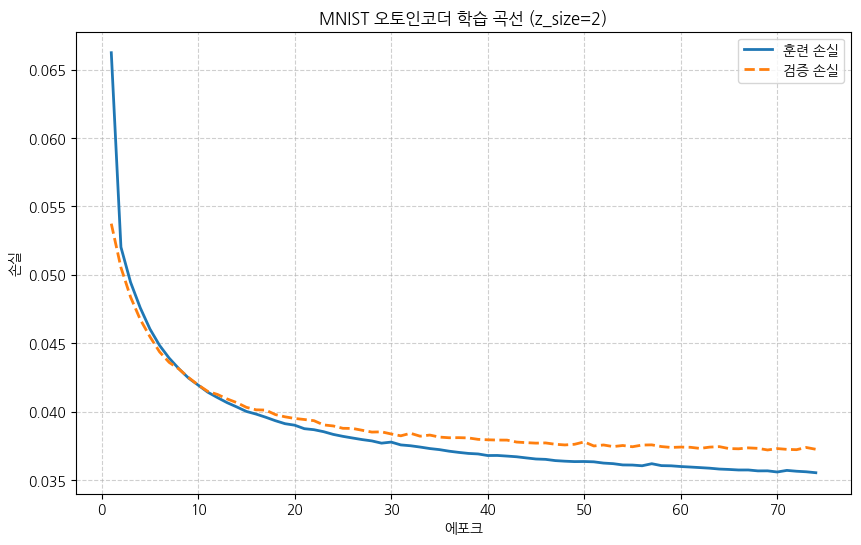

In [7]:
# 참고 - MNISTAutoEncoder 학습
import torch.optim as optim

# 결과 재현 및 고정을 위한 시드 재설정
common.set_seed()

Z_SIZE = 2                  # 잠재 벡터의 크기
LR = 0.001                  # 학습률
PATIENCE = 5                # 조기 종료 인내
EPOCHS = 100                # 상한. 조기 종료로 더 일찍 끝남.

model = MNISTAutoEncoder(z_size=Z_SIZE).to(device)
criterion = nn.MSELoss()                     # 평균제곱오차 손실
optimizer = optim.Adam(model.parameters(), lr=LR)

log = train(
    model, train_loader, valid_loader, criterion, optimizer,
    EPOCHS, device, patience=PATIENCE
)

log.plot('MNIST 오토인코더 학습 곡선 (z_size=2)')

- `Z_SIZE`를 2로 설정한 오토인코더는 `(784,)` 형태의 이미지 텐서를 `(2,)` 형태의 아주 작은 잠재 벡터로 압축한 뒤 다시 `(784,)`로 복원한다.
    - 다소 극단적인 압축이지만, 그만큼 오토인코더의 능력과 한계를 알아보기 좋다.

## 오토인코더의 동작 확인([그림 7-9])

- 평가 데이터셋의 첫 여덟 개 샘플을 입력해 재현한 결과를 위아래로 비교한다.

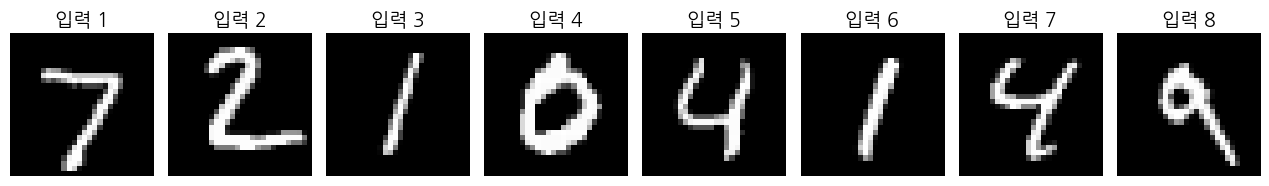

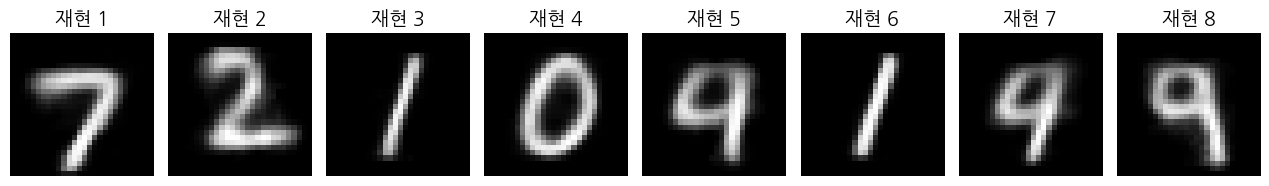

In [8]:
# 참고 - 평가 데이터셋 첫 8개 샘플과 재현 결과([그림 7-9])
model.eval()
num_show = 8
samples = [test_set[i][0] for i in range(num_show)]          # (784,) 텐서 8 개
inputs = torch.stack(samples).to(device)                     # (8, 784)
# 8개의 샘플을 학습된 오토인코더 모델에 입력해 재현 결과를 얻음
with torch.no_grad():
    outputs = model(inputs)                                  # (8, 784)

# 1D (784,) 텐서를 (28, 28)로 복원해 시각화
input_imgs = [s.view(28, 28) for s in samples]
output_imgs = [o.cpu().view(28, 28) for o in outputs]

descs_input = [f'입력 {i + 1}' for i in range(num_show)]
descs_output = [f'재현 {i + 1}' for i in range(num_show)]

viz.plot_images(input_imgs, descs_input, images_per_row=8)
viz.plot_images(output_imgs, descs_output, images_per_row=8)

- 원본과 재현 이미지를 비교하면 세 가지 사실을 확인할 수 있다.
    - **핵심 정보의 보존**: 784개의 픽셀을 크기 2의 잠재 벡터로 압축했다가 되돌렸음에도 원본의 전반적인 형태적 특성이 유지된다.
    - **세부 정보의 소실**: 가장 큰 차이를 만드는 특징 위주로 남아 세부 정보가 사라지고 뿌연 이미지로 재현된다.
    - **형태적 유사성에 따른 혼동**: 형태가 단순한 숫자 1은 가장 가깝게 재현되지만, 픽셀 분포가 비슷한 4와 9는 서로 혼동된다.

## 노이즈를 추가한 입력의 재현([그림 7-10])

- 세부 정보를 지우는 능력은 장점이 되기도 한다. 입력에 미세한 노이즈가 있으면 인코딩 과정에서 의미 없는 노이즈가 지워진다.
- 같은 입력 이미지에 평균 0, 표준편차 0.2인 분포의 노이즈를 추가해 재현해 본다.

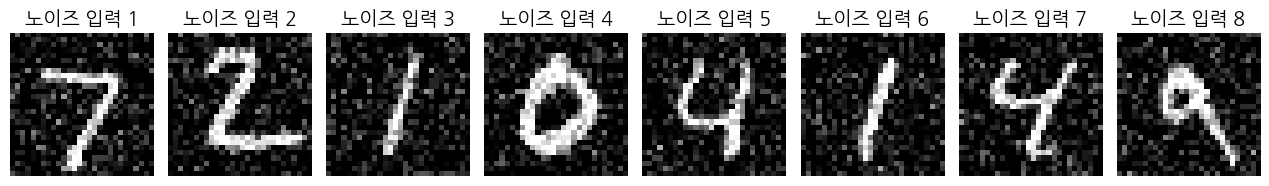

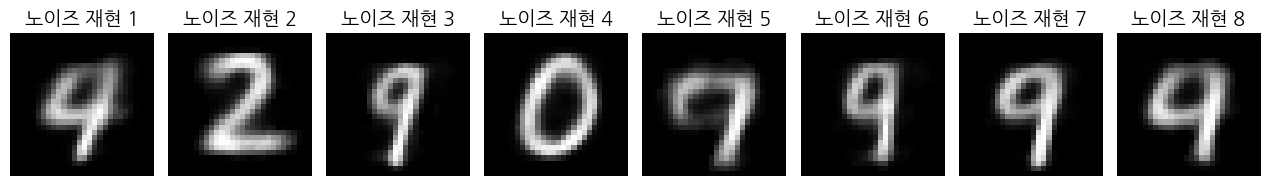

In [9]:
# 참고 - 노이즈를 추가한 입력의 재현([그림 7-10])
torch.manual_seed(SEED)                      # 재현성을 위해 시드 고정

# 원 픽셀 값에 0.2 표준편차의 정규분포 노이즈를 추가하고, 0~1 범위로 픽셀 범위 제한
noise = torch.randn_like(inputs) * 0.2
noisy_inputs = (inputs + noise).clamp(0.0, 1.0)              # 픽셀 범위 유지

with torch.no_grad():
    noisy_outputs = model(noisy_inputs)

noisy_input_imgs = [n.cpu().view(28, 28) for n in noisy_inputs]
noisy_output_imgs = [o.cpu().view(28, 28) for o in noisy_outputs]

descs_noisy_in = [f'노이즈 입력 {i + 1}' for i in range(num_show)]
descs_noisy_out = [f'노이즈 재현 {i + 1}' for i in range(num_show)]

viz.plot_images(noisy_input_imgs, descs_noisy_in, images_per_row=8)
viz.plot_images(noisy_output_imgs, descs_noisy_out, images_per_row=8)

- 자글자글한 노이즈가 추가된 원본과 달리 재현된 이미지에서는 노이즈를 찾아볼 수 없다.
    - 다만 대부분 다른 숫자로 바뀌는 부작용도 발생한다. 추가된 노이즈 때문에 인코더가 핵심 정보를 제대로 포착하지 못한 탓이다.
- 잠재 벡터가 너무 크면 남는 공간에 노이즈의 흔적까지 담겨 재현 결과에 노이즈가 살아나고, 너무 작으면 재현 품질 자체가 나빠진다.
    - 예제의 크기 2는 후자에 속한다.

## 정리

- 오토인코더는 인코더와 디코더로 구성한 모델을 입력과 정답이 같은 자기 지도 학습 방식으로 학습한 결과물이다.
- 출력층의 활성화 함수는 입력 데이터값의 범위에 맞춰 선택해야 하고, 데이터 변환 객체도 그 범위에 맞춰야 한다.
- 손실 함수로는 교차 엔트로피가 아니라 평균제곱오차나 평균절대오차를 사용한다.
- 잠재 벡터의 크기는 재현 품질과 노이즈에 대한 강건함을 함께 결정한다.